# Principal Component Analysis with Cancer Data

In [1]:
#Import all the necessary modules
#Import all the necessary modules
import pandas as pd
import numpy as np
import os
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

# Q1. Load the Data file into Python DataFrame and view top 10 rows

In [77]:
df = pd.read_csv('cancer.csv')
df.head(10)

,ID,ClumpThickness,Cell Size,Cell Shape,Marginal Adhesion,Single Epithelial Cell Size,Bare Nuclei,Normal Nucleoli,Bland Chromatin,Mitoses,Class
0,1000025,5,1,1,1,2,1,3,1,1,2
1,1002945,5,4,4,5,7,10,3,2,1,2
2,1015425,3,1,1,1,2,2,3,1,1,2
3,1016277,6,8,8,1,3,4,3,7,1,2
4,1017023,4,1,1,3,2,1,3,1,1,2
5,1017122,8,10,10,8,7,10,9,7,1,4
6,1018099,1,1,1,1,2,10,3,1,1,2
7,1018561,2,1,2,1,2,1,3,1,1,2
8,1033078,2,1,1,1,2,1,1,1,5,2
9,1033078,4,2,1,1,2,1,2,1,1,2


In [0]:
  # Id columns is to identify rows hence can be skipped in analysis
  # All columns have numerical values
  # Class would be the target variable. Should be removed when PCA is done

In [78]:
df.head()

,ID,ClumpThickness,Cell Size,Cell Shape,Marginal Adhesion,Single Epithelial Cell Size,Bare Nuclei,Normal Nucleoli,Bland Chromatin,Mitoses,Class
0,1000025,5,1,1,1,2,1,3,1,1,2
1,1002945,5,4,4,5,7,10,3,2,1,2
2,1015425,3,1,1,1,2,2,3,1,1,2
3,1016277,6,8,8,1,3,4,3,7,1,2
4,1017023,4,1,1,3,2,1,3,1,1,2


# Q2 Print the datatypes of each column and the shape of the dataset. Perform descriptive analysis 

In [100]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 585 entries, 299 to 662
Data columns (total 12 columns):
ClumpThickness                 585 non-null int64
Cell Size                      585 non-null int64
Cell Shape                     585 non-null int64
Marginal Adhesion              585 non-null int64
Single Epithelial Cell Size    585 non-null int64
Bare Nuclei                    585 non-null object
Normal Nucleoli                585 non-null int64
Bland Chromatin                585 non-null int64
Mitoses                        585 non-null int64
Class                          585 non-null int64
Class_zscore                   585 non-null float64
is_outlier                     585 non-null bool
dtypes: bool(1), float64(1), int64(9), object(1)
memory usage: 55.4+ KB


In [101]:
df.shape

(585, 12)

# Q3 Check for missing value check, incorrect data, duplicate data and perform imputation with mean, median, mode as necessary.


In [102]:
# We could see "?" values in column, this should be removed from data set

# Check for missing value in any other column

In [103]:
df = df.loc[df['Bare Nuclei'] != '?', :]
df.head()

,ClumpThickness,Cell Size,Cell Shape,Marginal Adhesion,Single Epithelial Cell Size,Bare Nuclei,Normal Nucleoli,Bland Chromatin,Mitoses,Class,Class_zscore,is_outlier
299,9,1,2,6,4,10,7,7,2,4,1.274095,False
330,10,4,7,2,2,8,6,1,1,4,1.274095,False
366,6,10,10,10,8,10,7,10,7,4,1.274095,False
243,1,1,1,1,2,5,5,1,1,2,-0.784871,False
571,7,6,10,5,3,10,9,10,2,4,1.274095,False


In [104]:
df.shape

(585, 12)

In [105]:
# No missing values found. So let us try to remove ? from bare nuclei column

# Get count of rows having ?


In [106]:
# 16 values are corrupted. We can either delete them as it forms roughly 2% of data.
# Here we would like to impute it with suitable values

# Q4. Perform bi variate analysis including correlation & pairplots. 


In [107]:
# Check for correlation of variable

In [108]:
df.corr()

,ClumpThickness,Cell Size,Cell Shape,Marginal Adhesion,Single Epithelial Cell Size,Normal Nucleoli,Bland Chromatin,Mitoses,Class,Class_zscore,is_outlier
ClumpThickness,1.000000,0.632236,0.648752,0.474311,0.498062,0.551989,0.522867,0.350526,0.721115,0.721115,NaN
Cell Size,0.632236,1.000000,0.900381,0.715329,0.741307,0.759118,0.721329,0.463936,0.814434,0.814434,NaN
Cell Shape,0.648752,0.900381,1.000000,0.692272,0.705460,0.734699,0.719733,0.441547,0.813876,0.813876,NaN
Marginal Adhesion,0.474311,0.715329,0.692272,1.000000,0.592802,0.665710,0.583983,0.402764,0.709752,0.709752,NaN
Single Epithelial Cell Size,0.498062,0.741307,0.705460,0.592802,1.000000,0.615562,0.628363,0.484246,0.679442,0.679442,NaN
Normal Nucleoli,0.551989,0.759118,0.734699,0.665710,0.615562,1.000000,0.659711,0.334060,0.750111,0.750111,NaN
Bland Chromatin,0.522867,0.721329,0.719733,0.583983,0.628363,0.659711,1.000000,0.421277,0.711611,0.711611,NaN
Mitoses,0.350526,0.463936,0.441547,0.402764,0.484246,0.334060,0.421277,1.000000,0.426173,0.426173,NaN
Class,0.721115,0.814434,0.813876,0.709752,0.679442,0.750111,0.711611,0.426173,1.000000,1.000000,NaN
Class_zscore,0.721115,0.814434,0.813876,0.709752,0.679442,0.750111,0.711611,0.426173,1.000000,1.000000,NaN


In [109]:
# Cell size shows high significance with cell shape,marginal adhesion, single epithelial cell size,bare nuclei, normal nucleoli 
# and bland chromatin
# Target variable shows high correlation with most of these variables

In [110]:
#Let us check for pair plots

C:\ProgramData\Anaconda3\lib\site-packages\scipy\stats\stats.py:1713: FutureWarning: Using a non-tuple sequence for multidimensional indexing is deprecated; use `arr[tuple(seq)]` instead of `arr[seq]`. In the future this will be interpreted as an array index, `arr[np.array(seq)]`, which will result either in an error or a different result.
  return np.add.reduce(sorted[indexer] * weights, axis=axis) / sumval
C:\ProgramData\Anaconda3\lib\site-packages\statsmodels\nonparametric\kde.py:488: RuntimeWarning: invalid value encountered in true_divide
  binned = fast_linbin(X, a, b, gridsize) / (delta * nobs)
C:\ProgramData\Anaconda3\lib\site-packages\statsmodels\nonparametric\kdetools.py:34: RuntimeWarning: invalid value encountered in double_scalars
  FAC1 = 2*(np.pi*bw/RANGE)**2
C:\ProgramData\Anaconda3\lib\site-packages\numpy\core\fromnumeric.py:83: RuntimeWarning: invalid value encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)


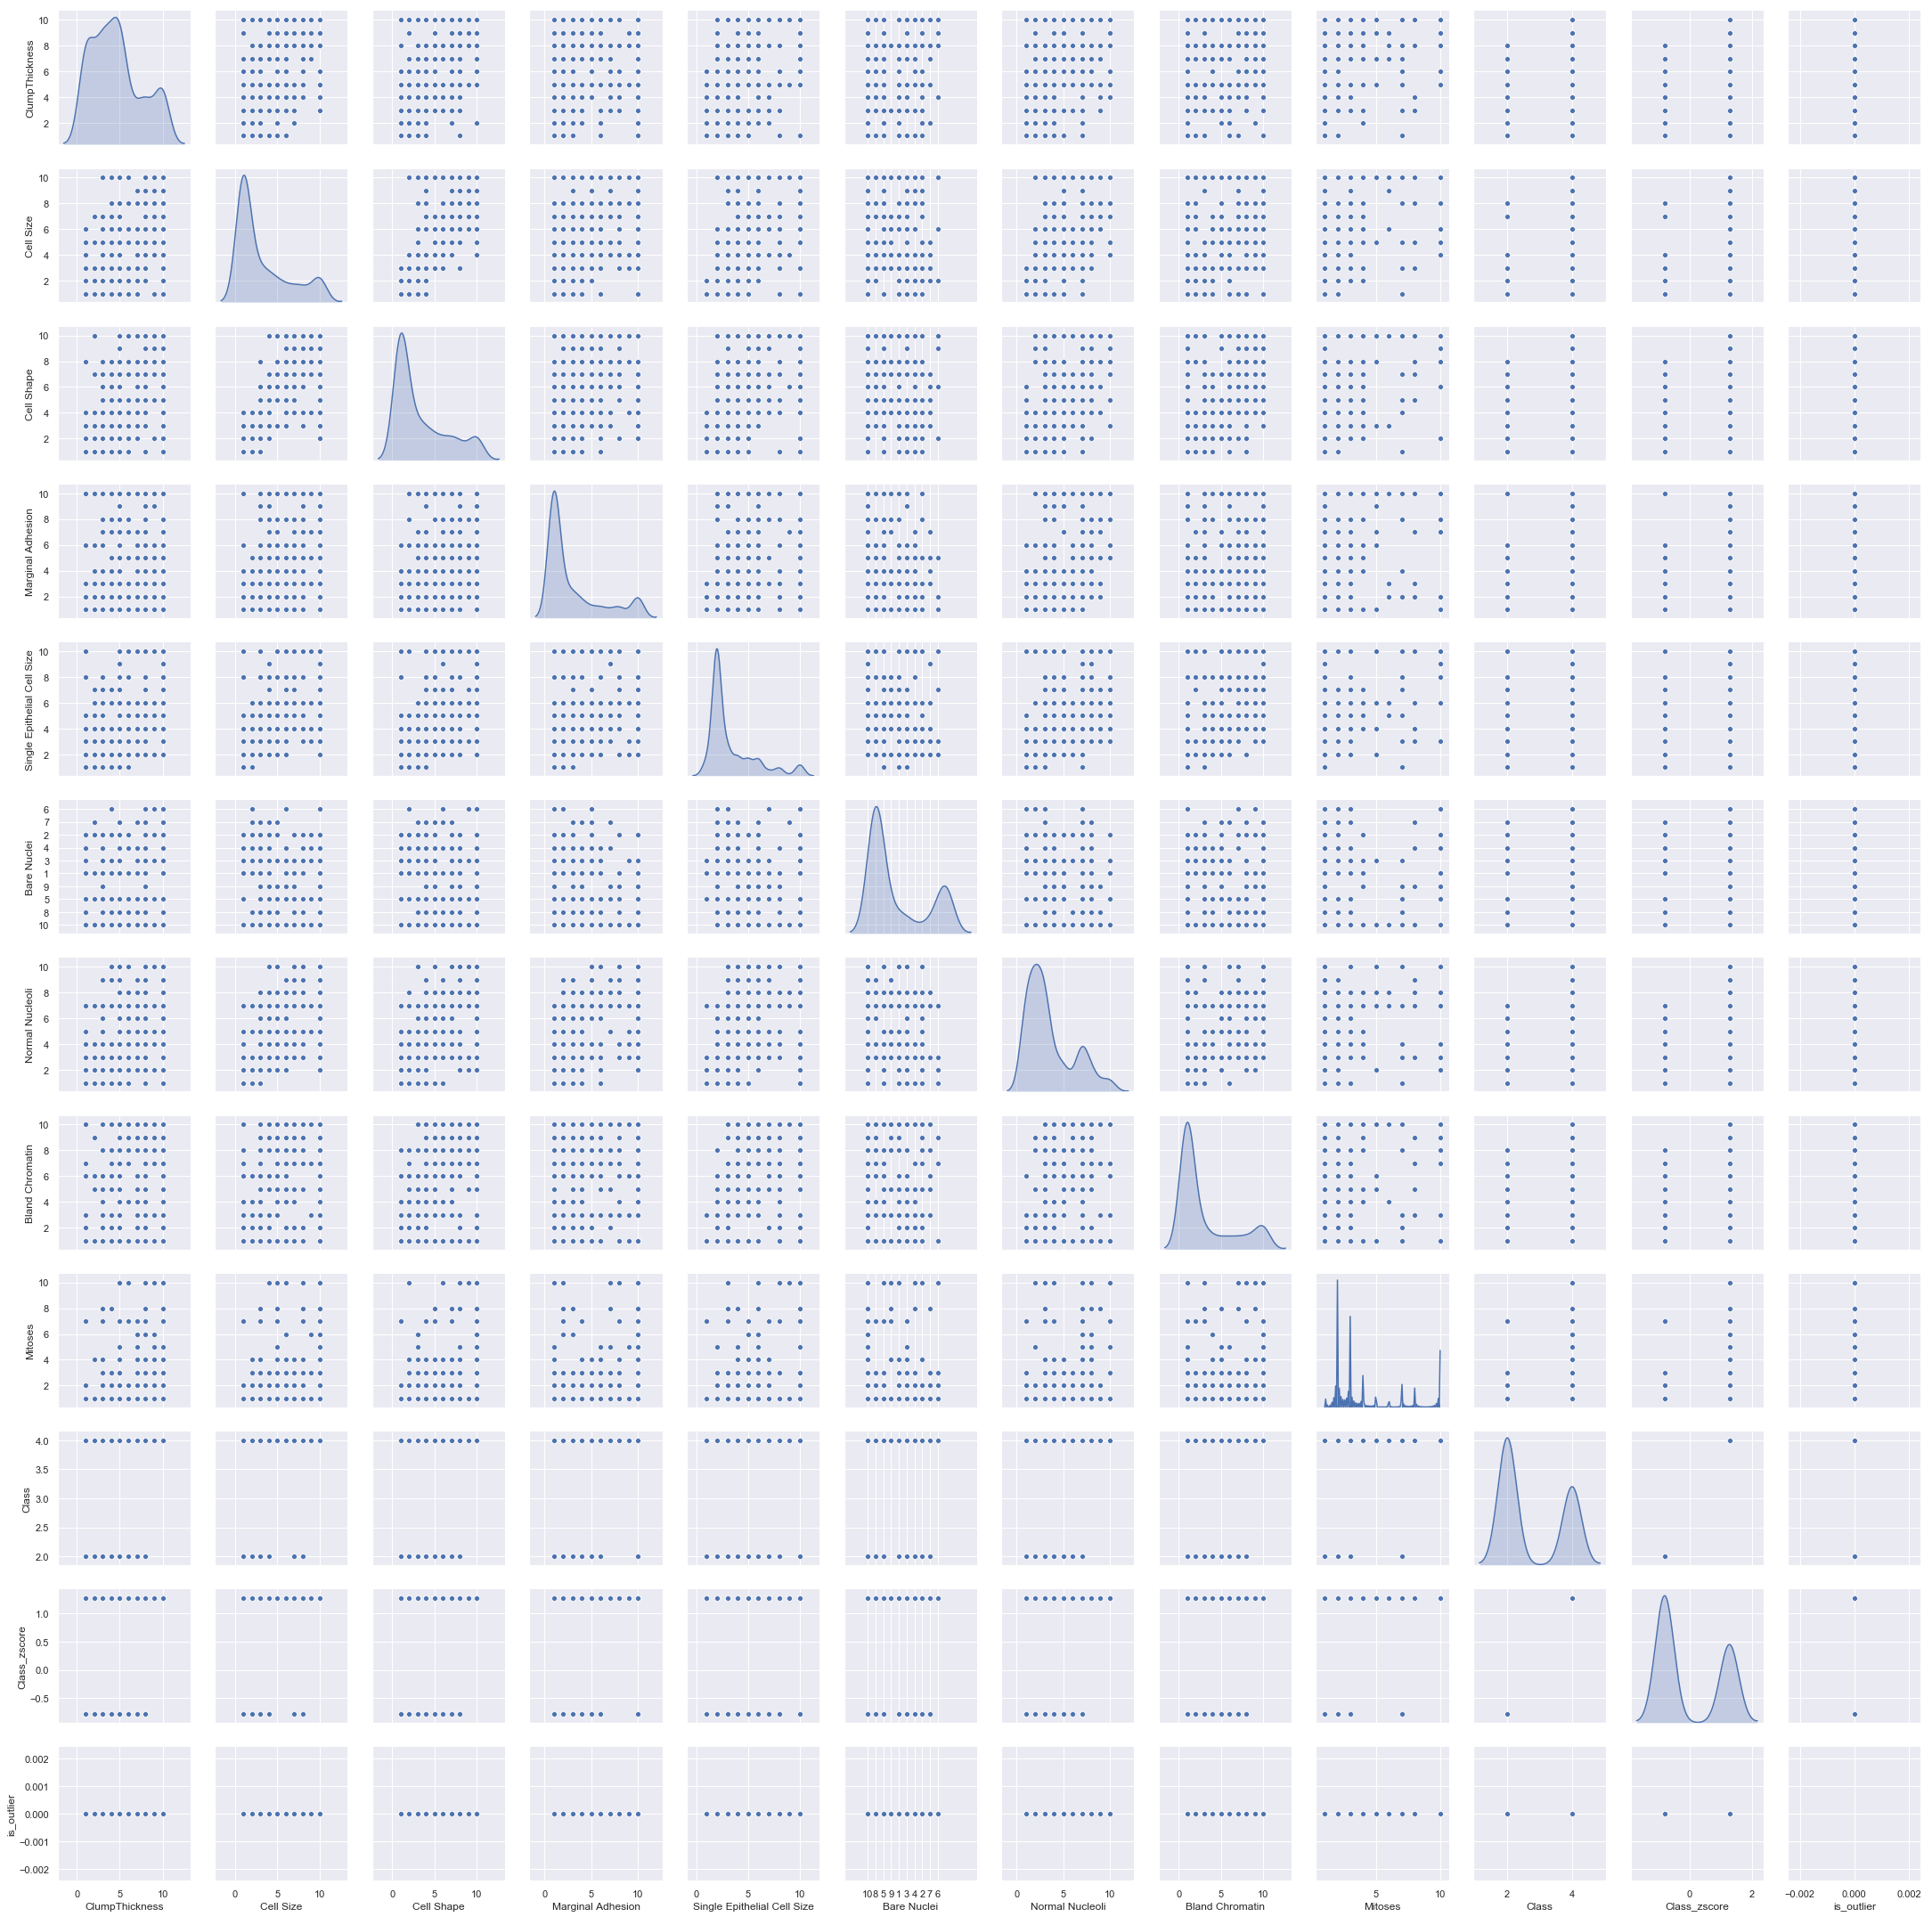

In [111]:
import seaborn as sns
sns.pairplot(df,diag_kind='kde')

# Q5 Remove any unwanted columns or outliers, standardize variables in this pre-processing step

In [0]:
# We could see most of the outliers are now removed.

In [113]:
df.sort_values("ID", inplace = True) 
# dropping ALL duplicte values 
df.drop_duplicates(subset ="ID", keep = False, inplace = True) 

KeyError: 'ID'

In [114]:
df.shape

(585, 12)

In [116]:
df.drop("ID",axis=1,inplace=True)

KeyError: "['ID'] not found in axis"

In [117]:
Class = df['Class']
dff = df.drop('Class', axis=1)

In [118]:
import numpy as np

def outliers_z_score(dff):
    threshold = 3

    mean_y = np.mean(dff)
    stdev_y = np.std(dff)
    z_scores = [(y - mean_y) / stdev_y for y in ys]
    return np.where(np.abs(z_scores) > threshold)

In [119]:
dff.shape

(585, 11)

In [120]:
from sklearn import preprocessing

In [121]:
standardized_X = preprocessing.scale(dff)

C:\ProgramData\Anaconda3\lib\site-packages\ipykernel_launcher.py:1: DataConversionWarning: Data with input dtype bool, int64, float64, object were all converted to float64 by the scale function.
  """Entry point for launching an IPython kernel.


In [127]:
dff.head()

,ClumpThickness,Cell Size,Cell Shape,Marginal Adhesion,Single Epithelial Cell Size,Bare Nuclei,Normal Nucleoli,Bland Chromatin,Mitoses,Class_zscore,is_outlier
299,9,1,2,6,4,10,7,7,2,1.274095,False
330,10,4,7,2,2,8,6,1,1,1.274095,False
366,6,10,10,10,8,10,7,10,7,1.274095,False
243,1,1,1,1,2,5,5,1,1,-0.784871,False
571,7,6,10,5,3,10,9,10,2,1.274095,False


In [128]:
dff.drop("Class_zscore",axis=1,inplace=True)

In [129]:
dff.drop("is_outlier",axis=1,inplace=True)

In [130]:
dff.head()

,ClumpThickness,Cell Size,Cell Shape,Marginal Adhesion,Single Epithelial Cell Size,Bare Nuclei,Normal Nucleoli,Bland Chromatin,Mitoses
299,9,1,2,6,4,10,7,7,2
330,10,4,7,2,2,8,6,1,1
366,6,10,10,10,8,10,7,10,7
243,1,1,1,1,2,5,5,1,1
571,7,6,10,5,3,10,9,10,2


# Q6 Create a covariance matrix for identifying Principal components

In [132]:
# PCA
# Step 1 - Create covariance matrix
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler


from sklearn.decomposition import PCA
from scipy.stats import zscore

In [133]:
sc = StandardScaler()
X_std =  sc.fit_transform(dff)          
cov_matrix = np.cov(X_std.T)
print('Covariance Matrix \n%s', cov_matrix)

Covariance Matrix 
%s [[1.00171233 0.63331826 0.6498631  0.47512338 0.49891529 0.592539
  0.55293406 0.52376195 0.35112667]
 [0.63331826 1.00171233 0.90192262 0.71655372 0.74257637 0.67985742
  0.76041737 0.72256387 0.46473   ]
 [0.6498631  0.90192262 1.00171233 0.69345759 0.70666793 0.70570499
  0.73595696 0.72096555 0.44230257]
 [0.47512338 0.71655372 0.69345759 1.00171233 0.59381678 0.68095035
  0.66684984 0.58498268 0.40345402]
 [0.49891529 0.74257637 0.70666793 0.59381678 1.00171233 0.57234032
  0.61661605 0.62943901 0.48507546]
 [0.592539   0.67985742 0.70570499 0.68095035 0.57234032 1.00171233
  0.67886432 0.57530984 0.33954861]
 [0.55293406 0.76041737 0.73595696 0.66684984 0.61661605 0.67886432
  1.00171233 0.66084035 0.33463212]
 [0.52376195 0.72256387 0.72096555 0.58498268 0.62943901 0.57530984
  0.66084035 1.00171233 0.42199859]
 [0.35112667 0.46473    0.44230257 0.40345402 0.48507546 0.33954861
  0.33463212 0.42199859 1.00171233]]


C:\ProgramData\Anaconda3\lib\site-packages\sklearn\preprocessing\data.py:625: DataConversionWarning: Data with input dtype int64, object were all converted to float64 by StandardScaler.
  return self.partial_fit(X, y)
C:\ProgramData\Anaconda3\lib\site-packages\sklearn\base.py:462: DataConversionWarning: Data with input dtype int64, object were all converted to float64 by StandardScaler.
  return self.fit(X, **fit_params).transform(X)


# Q7 Identify eigen values and eigen vector

In [0]:
# Step 2- Get eigen values and eigen vector

In [134]:
eigenvalues, eigenvectors = np.linalg.eig(cov_matrix)
print('Eigen Vectors \n%s', eigenvectors)
print('\n Eigen Values \n%s', eigenvalues)

Eigen Vectors 
%s [[ 0.2999261   0.13207911 -0.8720768  -0.00366235  0.01659592  0.04660471
  -0.31883712  0.13002964  0.10514681]
 [ 0.38199744  0.03144126  0.05673664 -0.73816444  0.16809532  0.12339494
   0.38398487  0.33723386 -0.01817171]
 [ 0.37848248  0.07237465 -0.01625348  0.65697648  0.14858423  0.07110466
   0.56586498  0.26373639  0.05232066]
 [ 0.33393651  0.09082795  0.3621166   0.05624691 -0.52424845 -0.02209564
  -0.37043273  0.38961142  0.42614836]
 [ 0.33428911 -0.19895112  0.20123893  0.07104336  0.31766306  0.71588185
  -0.30995089 -0.30386867  0.03636772]
 [ 0.33481963  0.26192497 -0.0631289  -0.09167817 -0.50581066  0.00665115
   0.29594653 -0.68073506  0.00526806]
 [ 0.34707406  0.24335927  0.16928675  0.07886715  0.01768828 -0.20724012
  -0.29532032  0.08824204 -0.80447234]
 [ 0.33503846 -0.02837009  0.13778452 -0.02245509  0.49849695 -0.62408136
  -0.14021014 -0.29059505  0.35408254]
 [ 0.22977195 -0.89435112 -0.11289581  0.01190566 -0.26265662 -0.17916619
   0

# Q8 Find variance and cumulative variance by each eigen vector

In [135]:

# Make a set of (eigenvalue, eigenvector) pairs
eig_pairs = [(eigenvalues[index], eigenvectors[:,index]) for index in range(len(eigenvalues))]

# Sort the (eigenvalue, eigenvector) pairs from highest to lowest with respect to eigenvalue
eig_pairs.sort()

eig_pairs.reverse()
print(eig_pairs)

# Extract the descending ordered eigenvalues and eigenvectors
eigvalues_sorted = [eig_pairs[index][0] for index in range(len(eigenvalues))]
eigvectors_sorted = [eig_pairs[index][1] for index in range(len(eigenvalues))]

# Let's confirm our sorting worked, print out eigenvalues
print('Eigenvalues in descending order: \n%s' %eigvalues_sorted)

[(5.8688877486953945, array([0.2999261 , 0.38199744, 0.37848248, 0.33393651, 0.33428911,
       0.33481963, 0.34707406, 0.33503846, 0.22977195])), (0.7875478623723522, array([ 0.13207911,  0.03144126,  0.07237465,  0.09082795, -0.19895112,
        0.26192497,  0.24335927, -0.02837009, -0.89435112])), (0.5584661774186614, array([-0.8720768 ,  0.05673664, -0.01625348,  0.3621166 ,  0.20123893,
       -0.0631289 ,  0.16928675,  0.13778452, -0.11289581])), (0.4809465473851996, array([ 0.01659592,  0.16809532,  0.14858423, -0.52424845,  0.31766306,
       -0.50581066,  0.01768828,  0.49849695, -0.26265662])), (0.3707387266080792, array([ 0.04660471,  0.12339494,  0.07110466, -0.02209564,  0.71588185,
        0.00665115, -0.20724012, -0.62408136, -0.17916619])), (0.3049360245105005, array([ 0.13002964,  0.33723386,  0.26373639,  0.38961142, -0.30386867,
       -0.68073506,  0.08824204, -0.29059505, -0.00656909])), (0.2948173431954674, array([ 0.10514681, -0.01817171,  0.05232066,  0.42614836

In [136]:
tot = sum(eigenvalues)
var_explained = [(i / tot) for i in sorted(eigenvalues, reverse=True)]  # an array of variance explained by each 
# eigen vector... there will be 8 entries as there are 8 eigen vectors)
cum_var_exp = np.cumsum(var_explained)  # an array of cumulative variance. There will be 8 entries with 8 th entry 
# cumulative reaching almost 100%

# Q9 Use PCA command from sklearn and find Principal Components. Transform data to components formed

In [137]:
from sklearn.decomposition import PCA

In [147]:
pca = PCA(n_components=9)
pca.fit(dff)

PCA(copy=True, iterated_power='auto', n_components=9, random_state=None,
  svd_solver='auto', tol=0.0, whiten=False)

In [150]:
X_pca = pd.DataFrame(pca.transform(dff))

In [151]:
X_pca.shape

(585, 9)

In [154]:
dfpca = pd.concat([dff, X_pca],axis=1)

# Q10 Find correlation between components and features

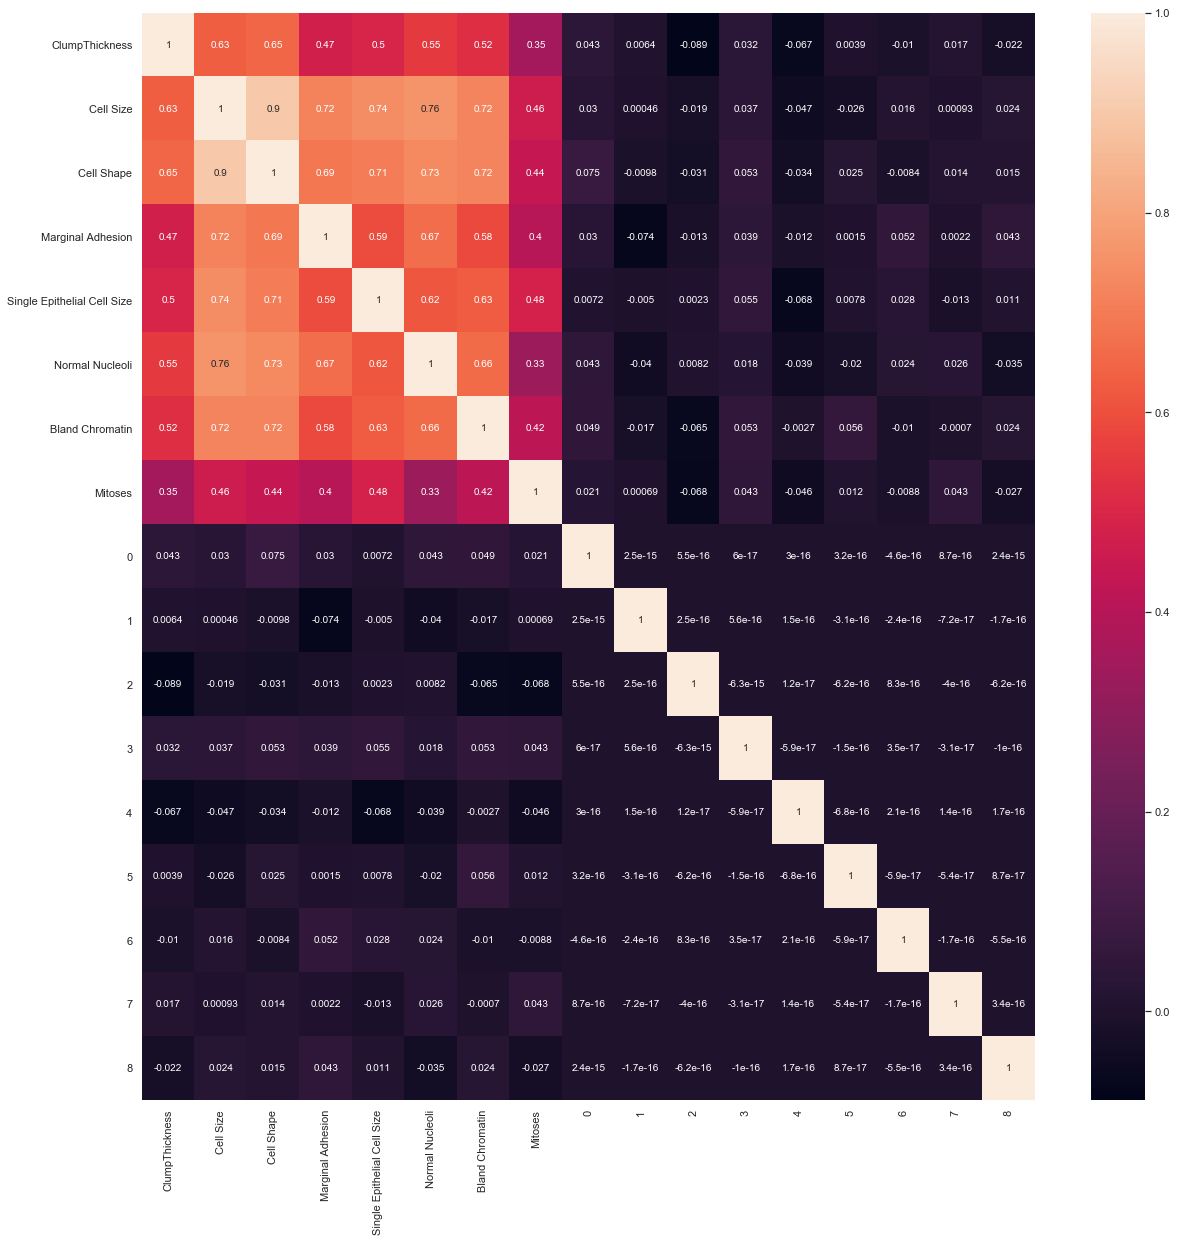

In [159]:
corr= dfpca.corr()
plt.figure(figsize= (20,20))
sns.heatmap(corr, annot=True)